W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
현재 적용 폰트: NanumGothic


Saving 시도별_경제활동별_지역내총생산_20260621110544.xlsx to 시도별_경제활동별_지역내총생산_20260621110544 (4).xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


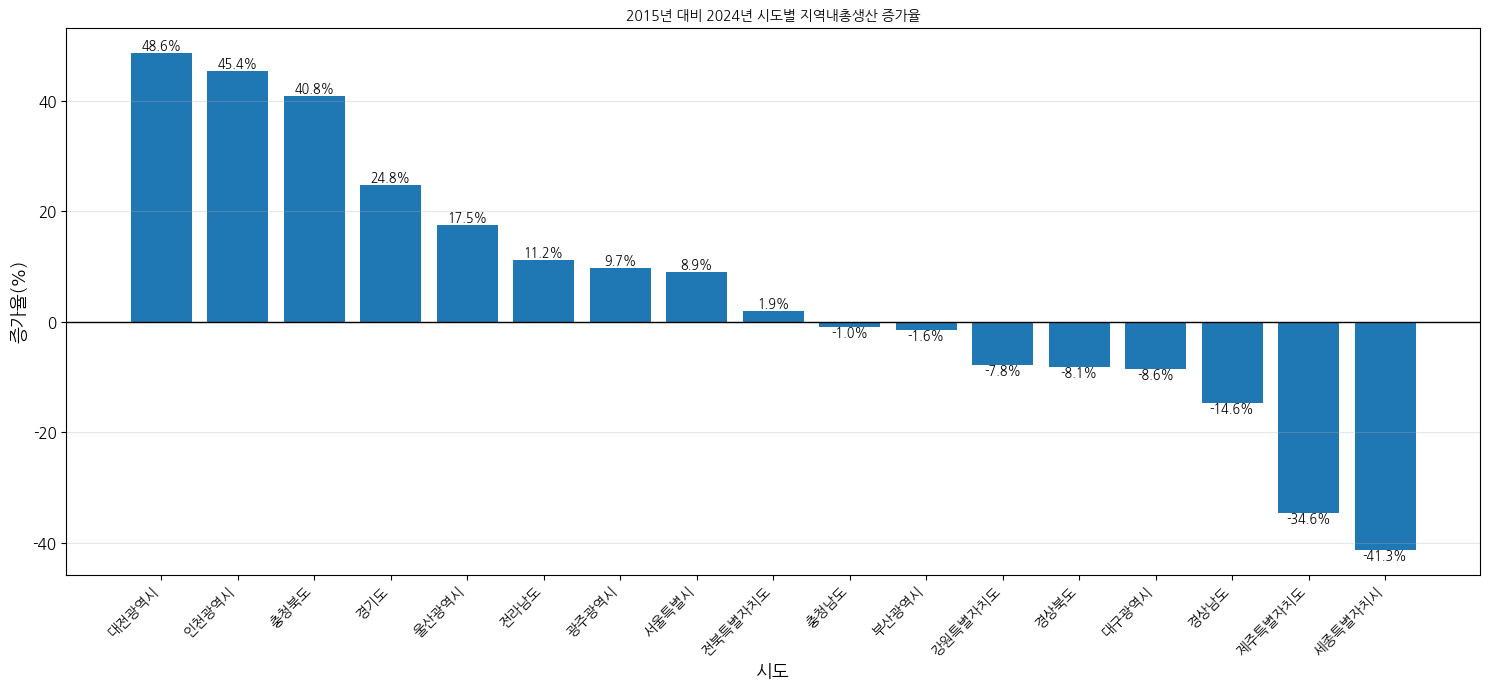


증가율 TOP 3
1. 대전광역시 | 2015년: 1,816,709 | 2024년: 2,698,959 | 증가율: 48.56%
2. 인천광역시 | 2015년: 4,532,354 | 2024년: 6,591,127 | 증가율: 45.42%
3. 충청북도 | 2015년: 3,304,962 | 2024년: 4,654,602 | 증가율: 40.84%

감소율 TOP 3 또는 증가율 하위 TOP 3
1. 세종특별자치시 | 2015년: 1,791,333 | 2024년: 1,051,606 | 증가율: -41.29%
2. 제주특별자치도 | 2015년: 1,792,914 | 2024년: 1,172,520 | 증가율: -34.60%
3. 경상남도 | 2015년: 6,761,268 | 2024년: 5,772,579 | 증가율: -14.62%


,시도,경제활동별,2015,2024,증가율(%)
0,대전광역시,건설업,1816709,2698959,48.563089
1,인천광역시,건설업,4532354,6591127,45.423923
2,충청북도,건설업,3304962,4654602,40.836778
3,경기도,건설업,23816531,29725667,24.811069
4,울산광역시,건설업,2972841,3491866,17.458889
5,전라남도,건설업,5077837,5647414,11.216922
6,광주광역시,건설업,1709411,1875390,9.709719
7,서울특별시,건설업,12783808,13927662,8.947678
8,전북특별자치도,건설업,3530358,3597965,1.915018
9,충청남도,건설업,7207843,7137387,-0.977491


In [ ]:

# ============================================================
# 시도별 지역내총생산 증가율 분석
# 한글 깨짐 방지 강제 적용 버전
# Google Colab 실행용
# ============================================================

!apt-get -qq update
!apt-get -qq install -y fonts-nanum
!rm -rf ~/.cache/matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
from google.colab import files

# ============================================================
# 1. 한글 폰트 강제 등록
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

print("현재 적용 폰트:", font_name)

# ============================================================
# 2. 파일 업로드
# ============================================================

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# ============================================================
# 3. 엑셀 읽기
# ============================================================

raw = pd.read_excel(file_name, sheet_name="데이터", header=None)

df = raw.iloc[2:].copy()

df.columns = [
    "시도", "경제활동별",
    "2015", "2016", "2017", "2018", "2019",
    "2020", "2021", "2022", "2023", "2024"
]

# ============================================================
# 4. 숫자형 변환
# ============================================================

for col in ["2015", "2024"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["시도", "2015", "2024"])

# ============================================================
# 5. 증가율 계산
# ============================================================

df["증가율(%)"] = (df["2024"] - df["2015"]) / df["2015"] * 100

result = df[["시도", "경제활동별", "2015", "2024", "증가율(%)"]].copy()
result = result.sort_values("증가율(%)", ascending=False)

# ============================================================
# 6. 그래프 시각화
# ============================================================

plt.figure(figsize=(15, 7))

bars = plt.bar(result["시도"], result["증가율(%)"])

plt.title(
    "2015년 대비 2024년 시도별 지역내총생산 증가율",
    fontsize=18,
    fontweight="bold",
    fontproperties=font_prop
)

plt.xlabel("시도", fontsize=13, fontproperties=font_prop)
plt.ylabel("증가율(%)", fontsize=13, fontproperties=font_prop)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=11,
    fontproperties=font_prop
)

plt.yticks(fontsize=11)

plt.axhline(0, color="black", linewidth=1)
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=9,
        fontproperties=font_prop
    )

plt.tight_layout()
plt.show()

# ============================================================
# 7. 증가율 TOP 3
# ============================================================

top3 = result.head(3)

print("\n" + "=" * 60)
print("증가율 TOP 3")
print("=" * 60)

for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(
        f"{i}. {row['시도']} | "
        f"2015년: {row['2015']:,.0f} | "
        f"2024년: {row['2024']:,.0f} | "
        f"증가율: {row['증가율(%)']:.2f}%"
    )

# ============================================================
# 8. 증가율 하위 TOP 3
# ============================================================

bottom3 = result.sort_values("증가율(%)", ascending=True).head(3)

print("\n" + "=" * 60)
print("감소율 TOP 3 또는 증가율 하위 TOP 3")
print("=" * 60)

for i, (_, row) in enumerate(bottom3.iterrows(), 1):
    print(
        f"{i}. {row['시도']} | "
        f"2015년: {row['2015']:,.0f} | "
        f"2024년: {row['2024']:,.0f} | "
        f"증가율: {row['증가율(%)']:.2f}%"
    )

# ============================================================
# 9. 전체 결과표
# ============================================================

display(result.reset_index(drop=True))